In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
import os

# Change this to your actual folder path in Drive
base_path = '/content/drive/MyDrive/ai_course/'

# Check what files are available
for f in os.listdir(base_path):
    print(f)

labels.npy
text_embeddings.npy
image_embeddings.npy
balanced_multimodal_welfake.csv
bilstm_baseline.pth


In [32]:
from google.colab import drive
drive.mount('/content/drive')

import os
base_path = '/content/drive/MyDrive/ai_course/'

text_embeddings = np.load(base_path + 'text_embeddings.npy')
labels          = np.load(base_path + 'labels.npy')

print(f"Text embeddings shape : {text_embeddings.shape}")
print(f"Labels shape          : {labels.shape}")
print(f"Label distribution    : {np.bincount(labels.astype(int))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Text embeddings shape : (43131, 768)
Labels shape          : (43131,)
Label distribution    : [12505 30626]


In [33]:
class_counts   = np.bincount(labels.astype(int))
class_weights  = 1.0 / class_counts
sample_weights = np.array([class_weights[int(l)] for l in labels])

print(f"Class counts  : Real={class_counts[0]}, Fake={class_counts[1]}")
print(f"Class weights : Real={class_weights[0]:.6f}, Fake={class_weights[1]:.6f}")

Class counts  : Real=12505, Fake=30626
Class weights : Real=0.000080, Fake=0.000033


In [34]:
class TextOnlyDataset(Dataset):
    def __init__(self, text_emb, labels):
        self.text_emb = torch.tensor(text_emb, dtype=torch.float32)
        self.labels   = torch.tensor(labels,   dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.text_emb[idx], self.labels[idx]


dataset = TextOnlyDataset(text_embeddings, labels)

train_size    = int(0.8 * len(dataset))
val_size      = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],
                                           generator=torch.Generator().manual_seed(42))

train_indices  = train_dataset.indices
train_sample_w = sample_weights[train_indices]
sampler        = WeightedRandomSampler(
                     weights     = torch.tensor(train_sample_w, dtype=torch.float32),
                     num_samples = len(train_indices),
                     replacement = True
                 )

train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

print(f"Train samples : {train_size}")
print(f"Val samples   : {val_size}")

Train samples : 34504
Val samples   : 8627


In [35]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super(AttentionLayer, self).__init__()
        self.attention_weights = nn.Linear(hidden_size, hidden_size)
        self.context_vector    = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_output):
        scores  = torch.tanh(self.attention_weights(lstm_output))
        scores  = self.context_vector(scores).squeeze(-1)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        output  = torch.sum(lstm_output * weights, dim=1)
        return output

In [36]:
class BiLSTM(nn.Module):
    def __init__(self, text_dim=768, proj_dim=128, seq_len=4, hidden_dim=64):
        super(BiLSTM, self).__init__()

        self.seq_len  = seq_len
        self.proj_dim = proj_dim

        self.text_proj  = nn.Linear(text_dim, proj_dim * seq_len)
        self.text_bn    = nn.BatchNorm1d(proj_dim * seq_len)
        self.dropout_in = nn.Dropout(0.3)

        self.bilstm = nn.LSTM(
            input_size    = proj_dim,
            hidden_size   = hidden_dim,
            num_layers    = 2,
            bidirectional = True,
            batch_first   = True,
            dropout       = 0.3
        )

        self.attention = AttentionLayer(hidden_dim * 2)

        self.fc1      = nn.Linear(hidden_dim * 2, 64)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2      = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3      = nn.Linear(32, 1)
        self.relu     = nn.ReLU()

    def forward(self, text_emb):
        x = self.text_proj(text_emb)
        x = self.text_bn(x)
        x = x.view(-1, self.seq_len, self.proj_dim)
        x = self.dropout_in(x)

        lstm_out, _ = self.bilstm(x)
        x = self.attention(lstm_out)

        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        return self.fc3(x).squeeze()

In [37]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0005):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = np.inf
        self.early_stop = False
        self.best_model = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_model = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter    = 0
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [38]:
def plot_results(train_losses, train_accs, val_losses, val_accs,
                 all_preds, all_labels, accuracy, precision, recall, f1):

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    axes[0, 0].plot(train_losses, label='Train Loss',     linewidth=2, color='blue')
    axes[0, 0].plot(val_losses,   label='Val Loss',       linewidth=2, color='orange')
    axes[0, 0].axvline(x=np.argmin(val_losses), color='red', linestyle='--', label='Best Model', alpha=0.7)
    axes[0, 0].set_title('Loss',     fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(train_accs, label='Train Accuracy', linewidth=2, color='blue')
    axes[0, 1].plot(val_accs,   label='Val Accuracy',   linewidth=2, color='orange')
    axes[0, 1].axvline(x=np.argmax(val_accs), color='red', linestyle='--', label='Best Model', alpha=0.7)
    axes[0, 1].set_title('Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    axes[1, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('True Label')
    axes[1, 0].set_xlabel('Predicted Label')

    metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [accuracy, precision, recall, f1]
    bars = axes[1, 1].bar(metrics_names, metrics_values,
                          color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
    axes[1, 1].set_title('Performance Metrics', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_ylim([0, 1.1])
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width() / 2., height,
                        f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()



In [51]:
def train_model(model, train_loader, val_loader, device, epochs=30, modality='text'):

    class_counts   = np.bincount(labels.astype(int))
    pos_weight     = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
    criterion      = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    #optimizer      = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) for one
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3) # for two
    scheduler      = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    early_stopping = EarlyStopping(patience=7, min_delta=0.0005)

    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    train_losses, train_accs = [], []
    val_losses,   val_accs   = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss, correct, total = 0, 0, 0

        for batch in train_loader:
            if modality == 'text':
                text_emb, y_batch = batch
                text_emb  = text_emb.to(device)
                y_batch   = y_batch.to(device)
                outputs   = model(text_emb)
            else:
                text_emb, image_emb, y_batch = batch
                text_emb  = text_emb.to(device)
                image_emb = image_emb.to(device)
                y_batch   = y_batch.to(device)
                outputs   = model(text_emb, image_emb)

            optimizer.zero_grad()
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            predicted   = (torch.sigmoid(outputs) > 0.5).float()
            total      += y_batch.size(0)
            correct    += (predicted == y_batch).sum().item()

        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(correct / total)

        model.eval()
        epoch_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for batch in val_loader:
                if modality == 'text':
                    text_emb, y_batch = batch
                    text_emb  = text_emb.to(device)
                    y_batch   = y_batch.to(device)
                    outputs   = model(text_emb)
                else:
                    text_emb, image_emb, y_batch = batch
                    text_emb  = text_emb.to(device)
                    image_emb = image_emb.to(device)
                    y_batch   = y_batch.to(device)
                    outputs   = model(text_emb, image_emb)

                loss        = criterion(outputs, y_batch)
                epoch_loss += loss.item()
                predicted   = (torch.sigmoid(outputs) > 0.5).float()
                total      += y_batch.size(0)
                correct    += (predicted == y_batch).sum().item()

        val_losses.append(epoch_loss / len(val_loader))
        val_accs.append(correct / total)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f} - Acc: {train_accs[-1]:.4f} - Val_Loss: {val_losses[-1]:.4f} - Val_Acc: {val_accs[-1]:.4f} - LR: {current_lr:.6f}")

        scheduler.step(val_losses[-1])
        early_stopping(val_losses[-1], model)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            model.load_state_dict(early_stopping.best_model)
            break

    if early_stopping.best_model is not None:
        model.load_state_dict(early_stopping.best_model)

    return train_losses, train_accs, val_losses, val_accs

In [48]:
def evaluate_model(model, val_loader, device, modality='text'):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            if modality == 'text':
                text_emb, y_batch = batch
                text_emb = text_emb.to(device)
                outputs  = model(text_emb)
            else:
                text_emb, image_emb, y_batch = batch
                text_emb  = text_emb.to(device)
                image_emb = image_emb.to(device)
                outputs   = model(text_emb, image_emb)

            predicted = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
            all_preds.extend(predicted)
            all_labels.extend(y_batch.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy  = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall    = recall_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return all_preds, all_labels, accuracy, precision, recall, f1

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = BiLSTM(
    text_dim  = 768,
    proj_dim  = 256,
    seq_len   = 4,
    hidden_dim= 4
).to(device)


train_losses, train_accs, val_losses, val_accs = train_model(
    model, train_loader, val_loader, device, epochs=30, modality='text'
)
all_preds, all_labels, accuracy, precision, recall, f1 = evaluate_model(
    model, val_loader, device, modality='text'
)

Using device: cuda
Model parameters: 801,105
Epoch 1/30 - Loss: 0.3700 - Acc: 0.6933 - Val_Loss: 0.2337 - Val_Acc: 0.7837 - LR: 0.000100
Epoch 2/30 - Loss: 0.2185 - Acc: 0.8491 - Val_Loss: 0.1943 - Val_Acc: 0.8412 - LR: 0.000100
Epoch 3/30 - Loss: 0.1929 - Acc: 0.8800 - Val_Loss: 0.1867 - Val_Acc: 0.8745 - LR: 0.000100
Epoch 4/30 - Loss: 0.1777 - Acc: 0.8978 - Val_Loss: 0.1812 - Val_Acc: 0.8863 - LR: 0.000100
Epoch 5/30 - Loss: 0.1690 - Acc: 0.9061 - Val_Loss: 0.1766 - Val_Acc: 0.8947 - LR: 0.000100
Epoch 6/30 - Loss: 0.1662 - Acc: 0.9109 - Val_Loss: 0.1792 - Val_Acc: 0.8965 - LR: 0.000100
EarlyStopping counter: 1 out of 3
Epoch 7/30 - Loss: 0.1597 - Acc: 0.9157 - Val_Loss: 0.1806 - Val_Acc: 0.8966 - LR: 0.000100
EarlyStopping counter: 2 out of 3
Epoch 8/30 - Loss: 0.1569 - Acc: 0.9192 - Val_Loss: 0.1788 - Val_Acc: 0.8972 - LR: 0.000100
EarlyStopping counter: 3 out of 3
Early stopping triggered!
Accuracy  : 0.8947
Precision : 0.9615
Recall    : 0.8863
F1 Score  : 0.9224


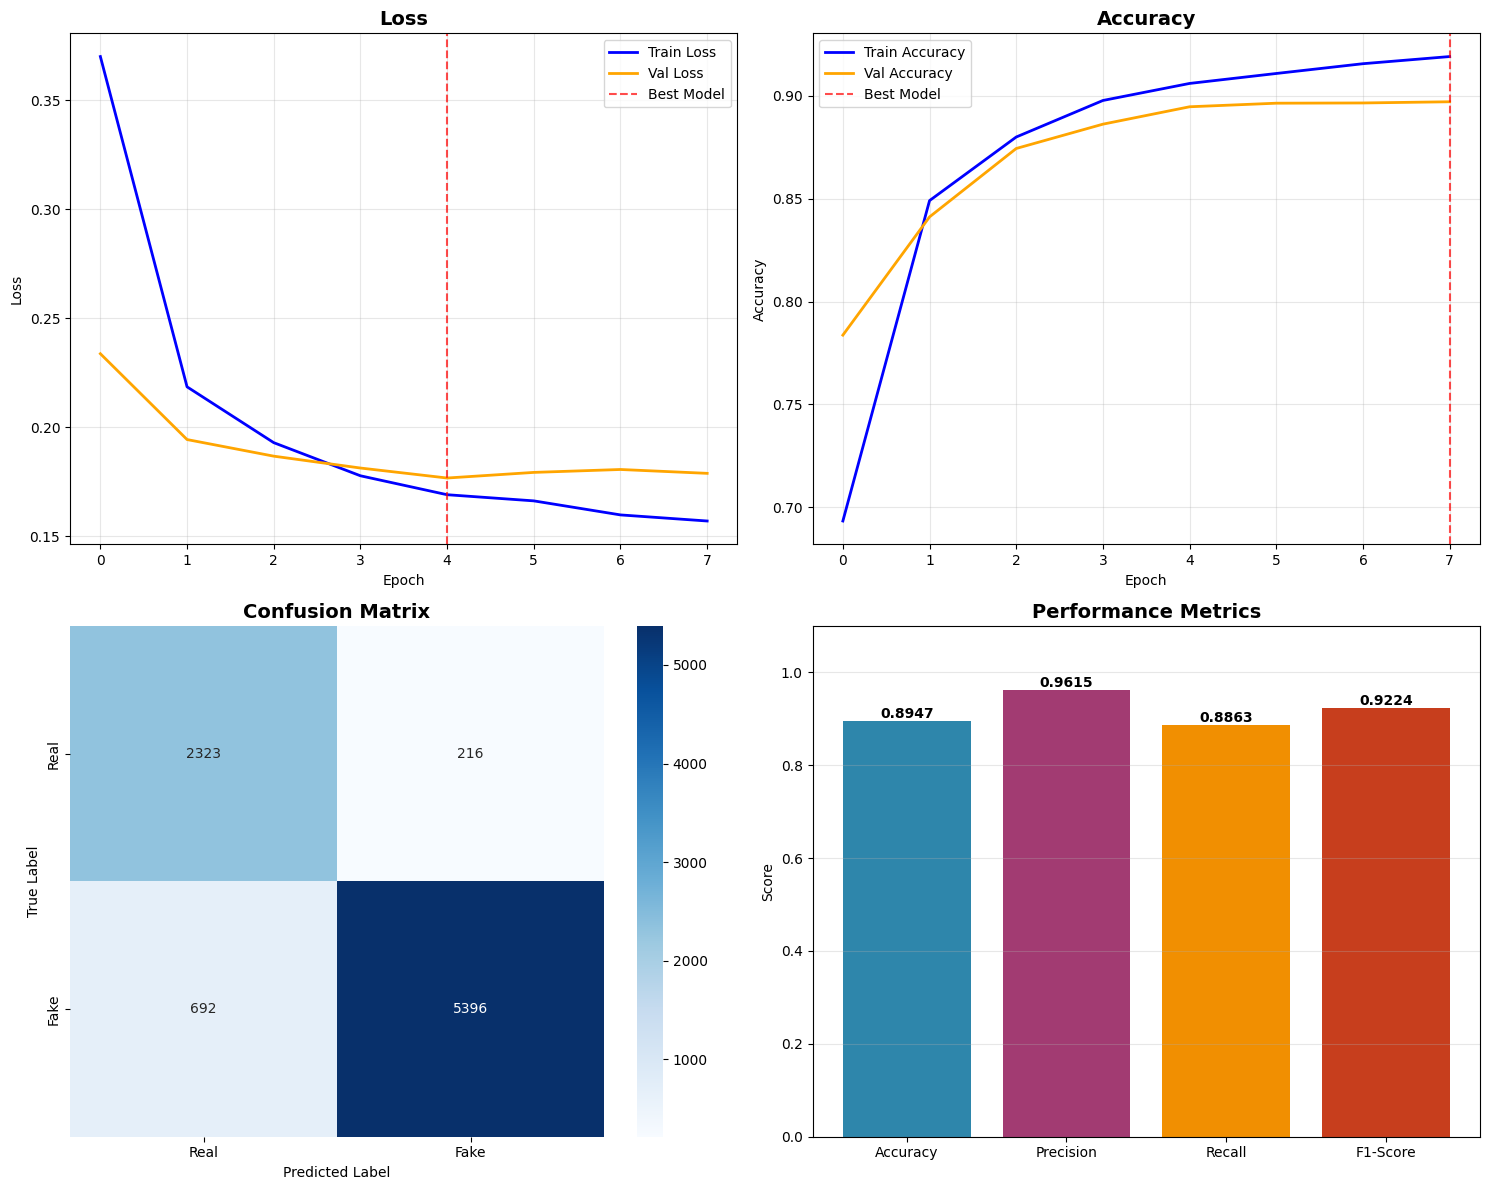

In [42]:
plot_results(train_losses, train_accs, val_losses, val_accs,
             all_preds, all_labels, accuracy, precision, recall, f1)

In [42]:
################# part 2 ####################################




In [52]:
class GatedFusionBiLSTM(nn.Module):
    def __init__(self, text_dim=768, image_dim=1280, proj_dim=128, seq_len=4, hidden_dim=64):
        super(GatedFusionBiLSTM, self).__init__()

        self.seq_len  = seq_len
        self.proj_dim = proj_dim

        # Project each modality to same dimension
        self.text_proj  = nn.Linear(text_dim,  proj_dim * seq_len)
        self.image_proj = nn.Linear(image_dim, proj_dim * seq_len)

        # Batch norm for each modality
        self.text_bn  = nn.BatchNorm1d(proj_dim * seq_len)
        self.image_bn = nn.BatchNorm1d(proj_dim * seq_len)

        # Gating mechanism — learns how much to trust text vs image
        self.gate = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.Sigmoid()
        )

        self.dropout_in = nn.Dropout(0.3)

        self.bilstm = nn.LSTM(
            input_size    = proj_dim,
            hidden_size   = hidden_dim,
            num_layers    = 2,
            bidirectional = True,
            batch_first   = True,
            dropout       = 0.3
        )

        self.attention = AttentionLayer(hidden_dim * 2)

        self.fc1      = nn.Linear(hidden_dim * 2, 64)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2      = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3      = nn.Linear(32, 1)
        self.relu     = nn.ReLU()

    def forward(self, text_emb, image_emb):
        # Project both modalities
        text_seq  = self.text_bn(self.text_proj(text_emb))
        image_seq = self.image_bn(self.image_proj(image_emb))

        # Reshape to sequence
        text_seq  = text_seq.view(-1, self.seq_len, self.proj_dim)
        image_seq = image_seq.view(-1, self.seq_len, self.proj_dim)

        # Gated fusion — gate decides per timestep how much text vs image to use
        combined = torch.cat([text_seq, image_seq], dim=-1)  # (batch, seq_len, proj_dim*2)
        gate     = self.gate(combined)                        # (batch, seq_len, proj_dim)
        x        = gate * text_seq + (1 - gate) * image_seq  # weighted fusion

        x = self.dropout_in(x)

        lstm_out, _ = self.bilstm(x)
        x = self.attention(lstm_out)

        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        return self.fc3(x).squeeze()

In [53]:
class MultiModalDataset(Dataset):
    def __init__(self, text_emb, image_emb, labels):
        self.text_emb  = torch.tensor(text_emb,  dtype=torch.float32)
        self.image_emb = torch.tensor(image_emb, dtype=torch.float32)
        self.labels    = torch.tensor(labels,    dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.text_emb[idx], self.image_emb[idx], self.labels[idx]

In [54]:
image_embeddings = np.load(base_path + 'image_embeddings.npy')

dataset = MultiModalDataset(text_embeddings, image_embeddings, labels)

train_size    = int(0.8 * len(dataset))
val_size      = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],
                                           generator=torch.Generator().manual_seed(42))

train_indices  = train_dataset.indices
train_sample_w = sample_weights[train_indices]
sampler        = WeightedRandomSampler(
                     weights     = torch.tensor(train_sample_w, dtype=torch.float32),
                     num_samples = len(train_indices),
                     replacement = True
                 )

train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

In [55]:
model = GatedFusionBiLSTM(
    text_dim  = 768,
    image_dim = 1280,
    proj_dim  = 128,
    seq_len   = 4,
    hidden_dim= 64
).to(device)

train_losses, train_accs, val_losses, val_accs = train_model(
    model, train_loader, val_loader, device, epochs=30, modality='multimodal'
)
all_preds, all_labels, accuracy, precision, recall, f1 = evaluate_model(
    model, val_loader, device, modality='multimodal'
)

Model parameters: 1,310,209
Epoch 1/30 - Loss: 0.2326 - Acc: 0.8500 - Val_Loss: 0.1913 - Val_Acc: 0.8823 - LR: 0.000500
Epoch 2/30 - Loss: 0.1790 - Acc: 0.8950 - Val_Loss: 0.1880 - Val_Acc: 0.8677 - LR: 0.000500
Epoch 3/30 - Loss: 0.1742 - Acc: 0.8987 - Val_Loss: 0.1799 - Val_Acc: 0.8834 - LR: 0.000500
Epoch 4/30 - Loss: 0.1680 - Acc: 0.9051 - Val_Loss: 0.1760 - Val_Acc: 0.8908 - LR: 0.000500
Epoch 5/30 - Loss: 0.1669 - Acc: 0.9060 - Val_Loss: 0.1819 - Val_Acc: 0.8877 - LR: 0.000500
EarlyStopping counter: 1 out of 7
Epoch 6/30 - Loss: 0.1607 - Acc: 0.9092 - Val_Loss: 0.1696 - Val_Acc: 0.8915 - LR: 0.000500
Epoch 7/30 - Loss: 0.1578 - Acc: 0.9145 - Val_Loss: 0.1683 - Val_Acc: 0.8950 - LR: 0.000500
Epoch 8/30 - Loss: 0.1567 - Acc: 0.9154 - Val_Loss: 0.1771 - Val_Acc: 0.8935 - LR: 0.000500
EarlyStopping counter: 1 out of 7
Epoch 9/30 - Loss: 0.1572 - Acc: 0.9160 - Val_Loss: 0.1757 - Val_Acc: 0.8941 - LR: 0.000500
EarlyStopping counter: 2 out of 7
Epoch 10/30 - Loss: 0.1543 - Acc: 0.9168 -

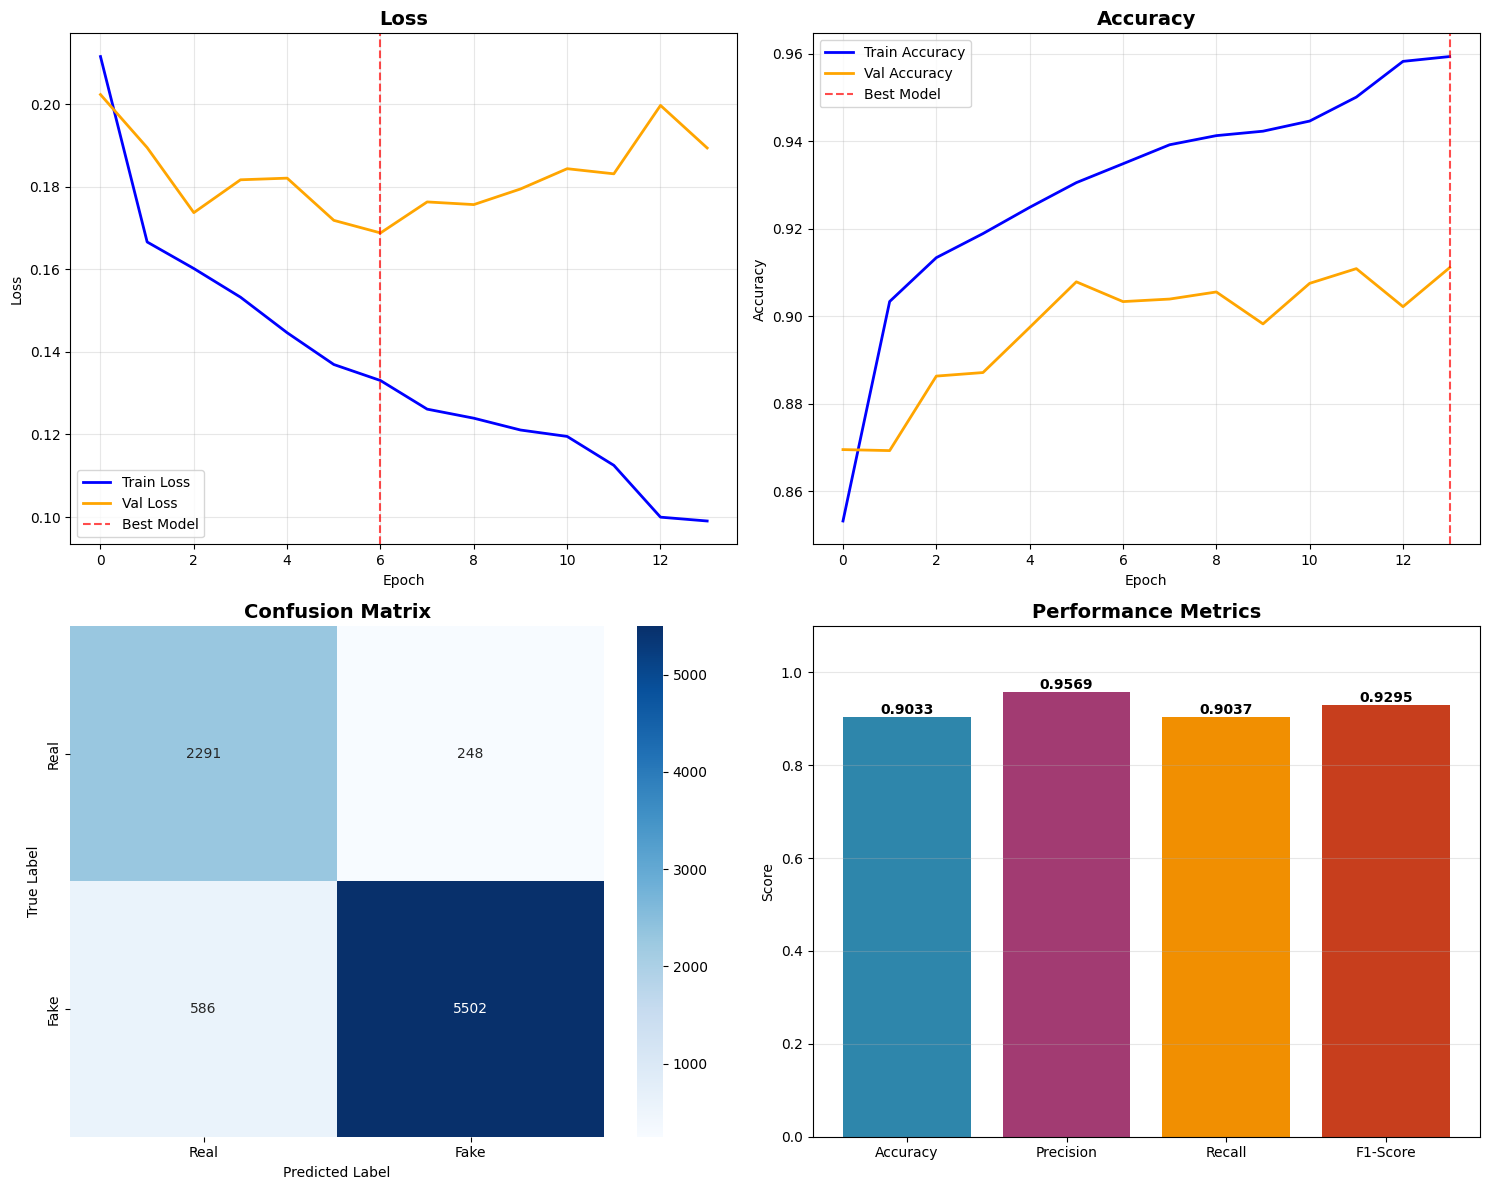

In [50]:
plot_results(train_losses, train_accs, val_losses, val_accs,
             all_preds, all_labels, accuracy, precision, recall, f1)